In [1]:
# A draft build up to mimic Citi's bubble methodology. The code is not complete and is a work in progress. Main aim of the methodology is to identify bubbles in the market. 
# Fundamental math is to create a real price index for a given stock using CPI, fitting it to a linear trend, and compare how the actual price index deviates from the trend.
# No design or methodology doc yet, all are just notes and code snippets.

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from datetime import datetime

In [3]:
cpi = pd.read_csv("CPIAUCSL.csv", index_col=0, parse_dates=True)
ndx = yf.download("^IXIC", start=cpi.index.min(), end=datetime.today().strftime('%Y-%m-%d'))["Close"].dropna()

# CPI is stamped on the 1st, so floor the start to the month or Feb-1971 gets cut.
cpi = cpi.loc[ndx.index.min().to_period('M').to_timestamp():]

print(ndx.head())
print(cpi.head())

[*********************100%***********************]  1 of 1 completed

Ticker           ^IXIC
Date                  
1971-02-05  100.000000
1971-02-08  100.839996
1971-02-09  100.760002
1971-02-10  100.690002
1971-02-11  101.449997
                  CPIAUCSL
observation_date          
1971-02-01            39.9
1971-03-01            40.0
1971-04-01            40.1
1971-05-01            40.3
1971-06-01            40.5


In [4]:
def price_index(price, cpi, warn=True):
    """
    Deflate a price series by CPI and return a monthly log real price index.

    price (df/series): daily nominal price.
    cpi   (df/series): CPI, stamped at month start (FRED CPIAUCSL convention).

    Returns a frame indexed by month end with columns nom, cpi, real, p (= log real).
    The index is contiguous monthly, which trend_z relies on.
    """
    price, cpi = price.squeeze(), cpi.squeeze()

    px = price.resample('ME').agg("mean")
    if price.index.max() < px.index.max():
        px = px.iloc[:-1]          # last month incomplete -> its mean is a partial month
    cp = cpi.resample('ME').last()

    months = pd.period_range(max(px.index.min(), cp.index.min()).to_period('M'),
                             min(px.index.max(), cp.index.max()).to_period('M'),
                             freq='M').to_timestamp('M')
    px, cp = px.reindex(months), cp.reindex(months)

    holes = cp.index[cp.isna()]
    if len(holes):
        # Oct-2025 is genuinely absent from CPIAUCSL (never published). Dropping it
        # would silently shorten the time axis every rolling window sees, so fill it.
        if warn:
            print("CPI missing:", ", ".join(holes.strftime('%Y-%m')), "-> interpolated")
        cp = cp.interpolate(limit_area='inside')

    df = pd.concat([px.rename("nom"), cp.rename("cpi")], axis=1).dropna()
    df["real"] = df["nom"] / df["cpi"]
    df["p"] = np.log(df["real"])
    return df

In [5]:
df = price_index(ndx, cpi)
print(df.shape, df.index.min().date(), "->", df.index.max().date())
df.tail(3)

CPI missing: 2025-10 -> interpolated
(666, 4) 1971-02-28 -> 2026-07-31


,nom,cpi,real,p
2026-05-31,26155.774609,333.979,78.315626,4.360747
2026-06-30,26074.847191,332.568,78.404558,4.361882
2026-07-31,25623.679954,332.813,76.991223,4.343691


In [6]:
def zcrit(window, sigma=2.0):
    """Threshold carrying the same tail area as `sigma` on a normal, at this window length.

    z is t-distributed with window-3 df, so a flat 2.0 is a slightly looser test on
    short windows. Use this when comparing windows against each other.
    """
    return float(stats.t.isf(stats.norm.sf(sigma), window - 3))


def trend_z(p, window=240, k=2.0):
    """Rolling detrend of monthly log real price -> trend, sd, z, upper.

    For each month t, fit a linear trend to the `window` months ENDING at t
    (no look-ahead), then measure t against that trend with t itself deleted
    from the fit. trend/sd/upper are therefore what the rest of the window
    implies for month t, and z is t's deviation in units of its own standard
    error -- distributed t(window-3) under a trend-stationary null.

    Deleting t matters because the endpoint of a linear fit is its highest
    leverage point: an in-sample residual there is shrunk by sqrt(1-h), which
    is 16% at window=12 and under 1% at window=240. Left uncorrected that
    makes z incomparable across window lengths.
    """
    n, v = window, p.to_numpy(float)
    if n < 5:
        raise ValueError("window must be >= 5")
    step = p.index.to_period('M')
    if len(step) and (np.diff(step.astype('int64')) != 1).any():
        raise ValueError("p must be contiguous monthly; gaps break the time axis")

    tc = np.arange(n) - (n - 1) / 2          # centred time, so intercept = window mean
    denom = (tc ** 2).sum()
    h = 1 / n + tc[-1] ** 2 / denom          # leverage of the last point in the window

    Y = np.lib.stride_tricks.sliding_window_view(v, n)
    slope = (Y @ tc) / denom
    fit = Y.mean(1)[:, None] + slope[:, None] * tc
    r = Y - fit
    r_end = r[:, -1]

    # scale from the window with month t deleted -> not inflated by the point being tested
    s2 = np.maximum((( r ** 2).sum(1) - r_end ** 2 / (1 - h)) / (n - 3), 0.0)
    sd = np.sqrt(s2) / np.sqrt(1 - h)        # std error of the out-of-sample deviation
    trend = (fit[:, -1] - h * Y[:, -1]) / (1 - h)     # trend excluding month t

    with np.errstate(divide="ignore", invalid="ignore"):
        z = np.where(sd > 0, (Y[:, -1] - trend) / sd, np.nan)

    return pd.DataFrame({"trend": trend, "sd": sd, "z": z, "upper": trend + k * sd},
                        index=p.index[n - 1:])

In [7]:
for w in (12, 24, 36, 60, 84, 120, 240, 360):
    kw = zcrit(w)
    z = trend_z(df["p"], w, k=kw)["z"]
    ent = z.index[(z > kw) & ~(z.shift(1, fill_value=0) > kw)]
    print(w, round(kw, 2), (z > kw).mean().round(3), list(ent.strftime("%Y-%m")))

12 2.32 0.047 ['1972-02', '1973-10', '1975-01', '1977-01', '1978-04', '1982-09', '1984-08', '1985-02', '1986-02', '1987-02', '1989-02', '1990-06', '1991-02', '1992-01', '1992-12', '1995-07', '1999-01', '1999-11', '2002-11', '2004-11', '2009-04', '2012-02', '2018-01', '2020-01']
24 2.13 0.068 ['1975-02', '1978-04', '1978-08', '1980-09', '1982-10', '1985-02', '1986-03', '1991-03', '1995-05', '1997-07', '1999-12', '2001-12', '2003-06', '2009-08', '2020-07', '2023-05']
36 2.08 0.057 ['1975-04', '1978-05', '1978-08', '1983-04', '1986-02', '1992-01', '1995-07', '1999-01', '1999-12', '2003-05', '2020-06', '2020-12']
60 2.04 0.035 ['1980-09', '1983-04', '1992-01', '1996-05', '1997-09', '1999-01', '1999-11', '2020-08', '2020-12']
84 2.03 0.043 ['1983-04', '1992-02', '1999-01', '1999-07', '1999-11', '2020-07']
120 2.02 0.06 ['1983-05', '1995-09', '1996-05', '1997-08', '1999-01', '1999-07', '1999-09', '1999-11', '2013-12', '2020-08', '2020-10', '2021-06']
240 2.01 0.145 ['1995-08', '1995-11', '19

In [8]:
def plot_trend_z(p, tz, title=None, start=None, crit=2.0):
    """p: monthly log real price. tz: output of trend_z."""
    p = p.reindex(tz.index)
    bub = tz["z"] > crit
    fig, (ax, bx) = plt.subplots(
        2, 1, figsize=(11, 6), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

    ax.plot(p.index, p, lw=1.2, color="#534AB7", label="log real price")
    ax.plot(tz.index, tz["trend"], lw=1, color="#888780", label="rolling trend")
    ax.plot(tz.index, tz["upper"], lw=1, ls="--", color="#BA7517", label=f"+{crit:.2f}σ")
    ax.fill_between(tz.index, tz["trend"], tz["upper"],
                    color="#FAC775", alpha=.18, lw=0)
    lo, hi = ax.get_ylim()
    ax.fill_between(tz.index, lo, hi, where=bub, color="#E24B4A",
                    alpha=.12, lw=0, label="bubble state")
    ax.set_ylim(lo, hi)
    ax.set_xlim(start or p.index.min(), p.index.max())
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    ax.set_ylabel("log real price")
    if title: ax.set_title(title, fontsize=11, loc="left")

    bx.plot(tz.index, tz["z"], lw=1, color="#1D9E75")
    bx.axhline(crit, lw=.8, ls="--", color="#BA7517")
    bx.axhline(0, lw=.8, color="#888780")
    bx.fill_between(tz.index, crit, tz["z"], where=bub, color="#E24B4A", alpha=.25, lw=0)
    bx.set_ylabel("z")

    entries = tz.index[bub & ~bub.shift(1, fill_value=False)]
    for d in entries:
        ax.axvline(d, lw=.7, color="#A32D2D", alpha=.6)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False); bx.spines[s].set_visible(False)
    return fig, (ax, bx), entries

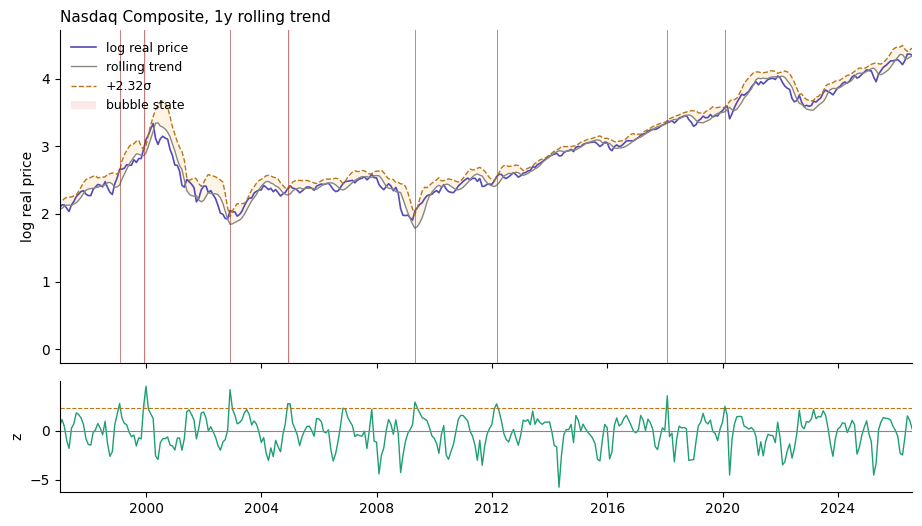

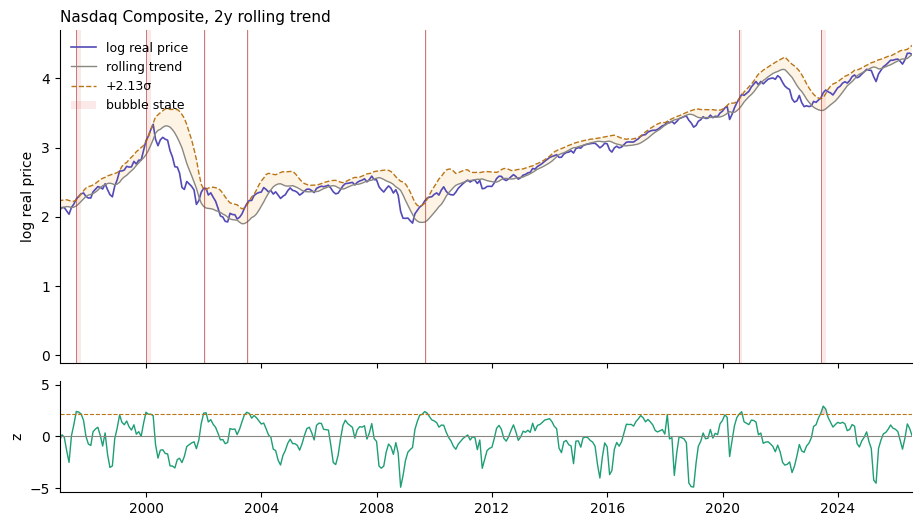

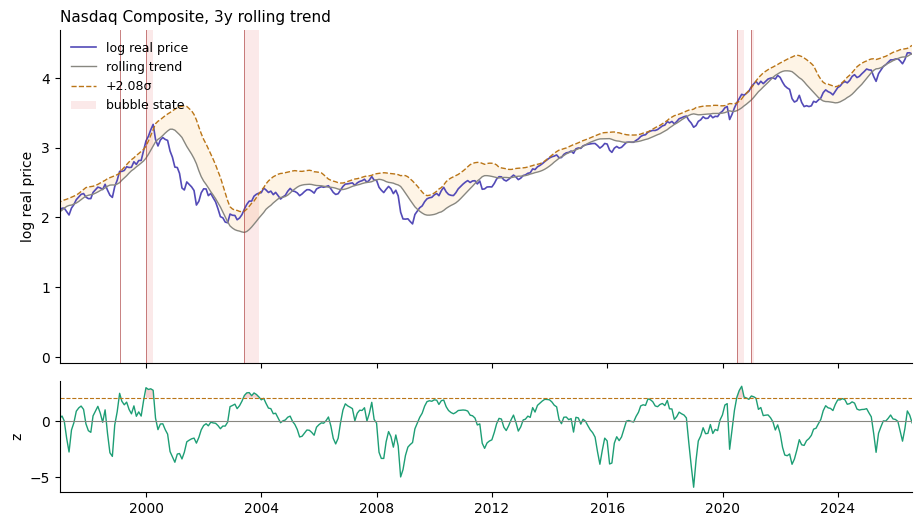

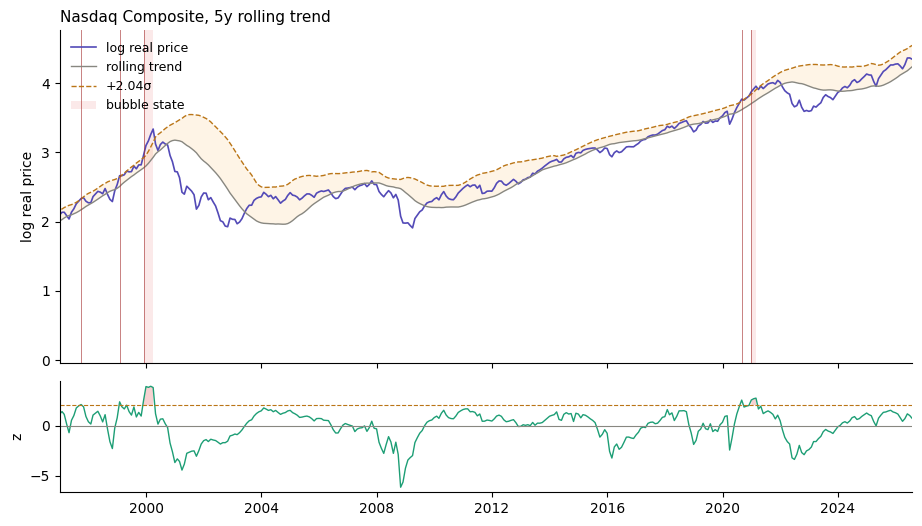

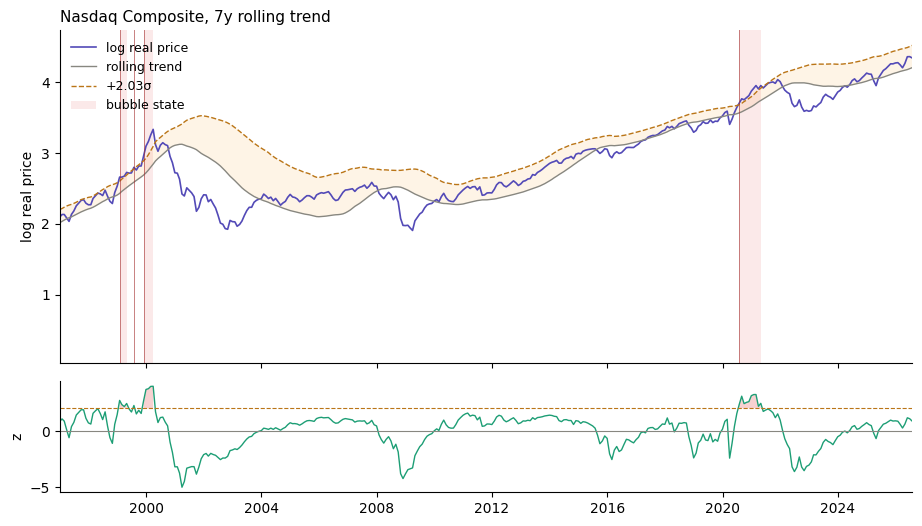

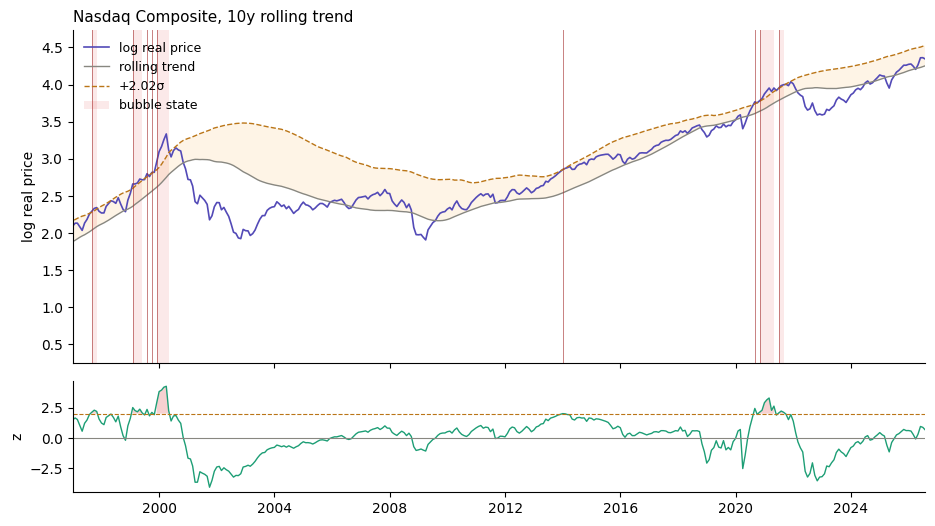

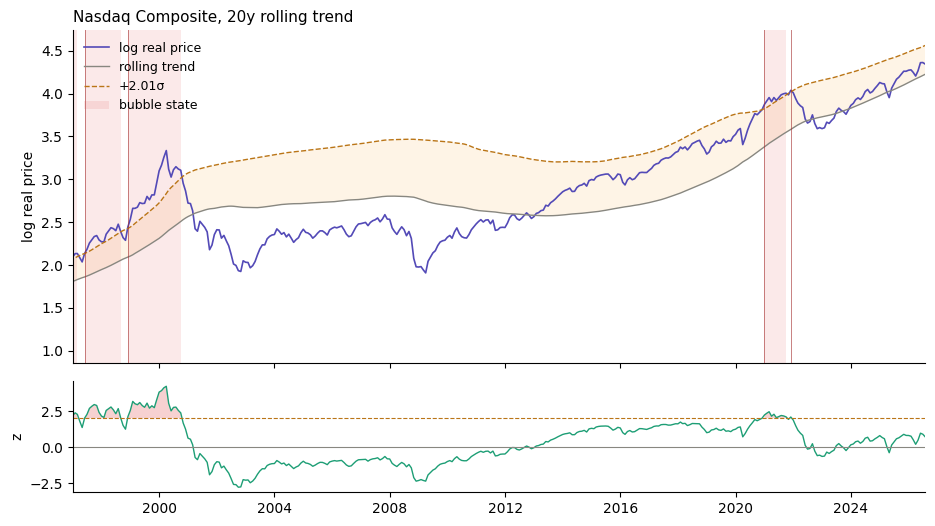

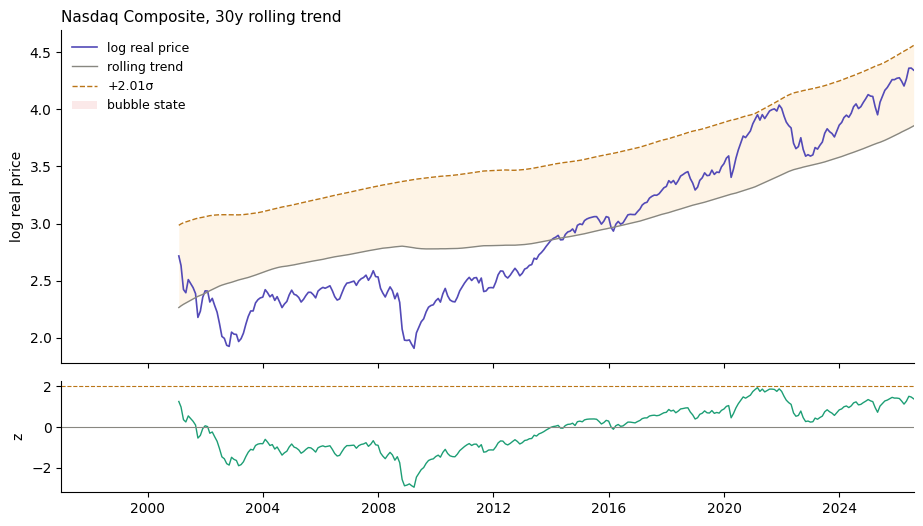

In [11]:
for w in (12, 24, 36, 60, 84, 120, 240, 360):
    kw = zcrit(w)
    tz = trend_z(df["p"], w, k=kw)
    fig, axes, entries = plot_trend_z(df["p"], tz, f"Nasdaq Composite, {w/12:.0f}y rolling trend", crit=kw, start=datetime(1997, 1, 1))